## LSTM + GRU Stock Predictor

In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn


In [4]:
tickers = ["AAPL", "MSFT", "GOOG"]

def load_multiple_stocks(tickers, periods="2y"):
    dfs = []
    for ticker in tickers:
        df = yf.download(ticker, period=periods)
        df = df[['Close']]
        df.columns = [ticker]
        dfs.append(df)

    combined = pd.concat(dfs, axis=1)
    combined.dropna(inplace=True)
    return combined

df = load_multiple_stocks(tickers)
df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,AAPL,MSFT,GOOG
Date,,,
2024-03-21,169.824432,422.879333,147.528793
2024-03-22,170.726242,422.258850,150.534134
2024-03-25,169.309143,416.467773,149.919144
2024-03-26,168.179443,415.276062,150.464676
2024-03-27,171.746948,415.059326,150.702744


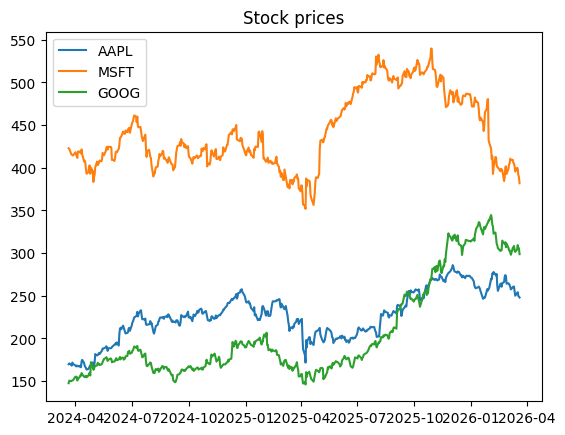

In [5]:
plt.Figure(figsize=(12,6))
for col in df.columns:
    plt.plot(df[col], label=col)

plt.title("Stock prices")
plt.legend()
plt.show()

In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.values)

In [7]:
def create_seq(data, seq_len=60):
    X, y = [], []

    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN=60
X, y = create_seq(scaled_data, SEQ_LEN)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (441, 60, 3)
y shape: (441, 3)


In [8]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [9]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=50, num_layers=2):
        super().__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [11]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=50, num_layers=2):
        super().__init__()
        
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, input_size)
        
    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [12]:
input_size = X.shape[2]

hidden_sizes = [32, 50]
num_layers_list = [1, 2]
learning_rates = [0.001, 0.0005]

best_loss = float('inf')
best_config = None

for hidden_size in hidden_sizes:
    for num_layers in num_layers_list:
        for lr in learning_rates:
            
            model = LSTMModel(input_size, hidden_size, num_layers)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            criterion = nn.MSELoss()
            
            for epoch in range(3):
                outputs = model(X_train)
                loss = criterion(outputs, y_train)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
            print(f"HS:{hidden_size}, NL:{num_layers}, LR:{lr}, Loss:{loss.item():.5f}")
            
            if loss.item() < best_loss:
                best_loss = loss.item()
                best_config = (hidden_size, num_layers, lr)

print("Best config:", best_config)

HS:32, NL:1, LR:0.001, Loss:0.22928
HS:32, NL:1, LR:0.0005, Loss:0.27776
HS:32, NL:2, LR:0.001, Loss:0.25326
HS:32, NL:2, LR:0.0005, Loss:0.17911
HS:50, NL:1, LR:0.001, Loss:0.11360
HS:50, NL:1, LR:0.0005, Loss:0.32185
HS:50, NL:2, LR:0.001, Loss:0.15134
HS:50, NL:2, LR:0.0005, Loss:0.20093
Best config: (50, 1, 0.001)
